# 02 — Spectrogram vs mel-spectrogram

Draw a plain (linear) spectrogram and a mel-spectrogram of the same clip, for both the
16 kHz and 8 kHz versions, and compare. Run `01_sampling_resampling.ipynb` first so the
resampled files exist in `audio_lab/outputs/`.

In [1]:
print("sahil")

sahil


Saved ../outputs/spectrogram_16k.png


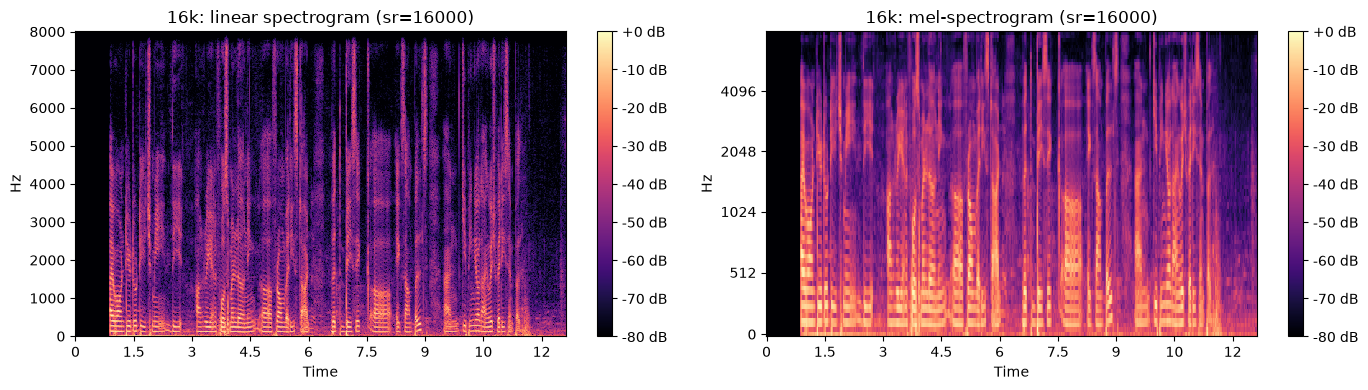

Saved ../outputs/spectrogram_8k.png


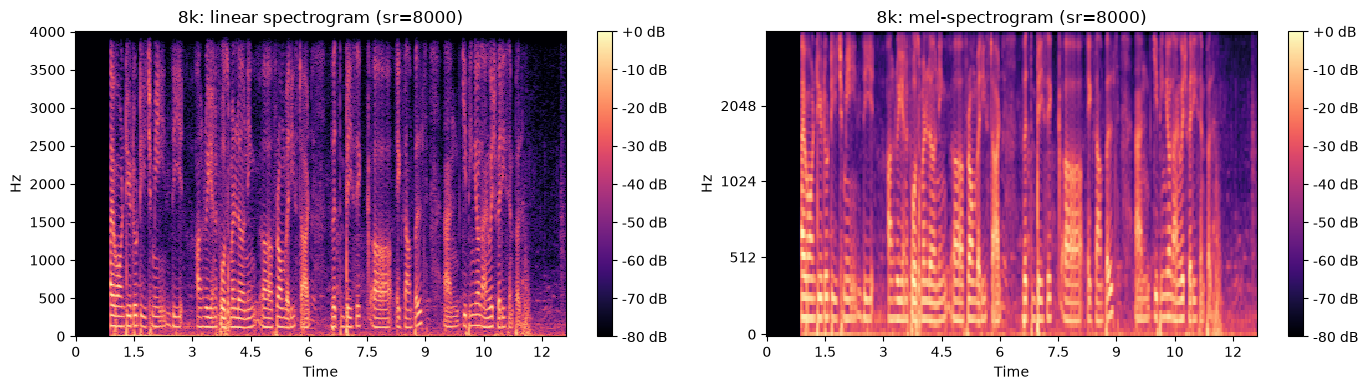


Look at: how much of the top of the linear spectrogram is empty for the 8k clip
(that's the frequency content that got thrown away), and how the mel-spectrogram
spaces its bands: closer together at low frequencies, wider apart at high ones,
matching how human hearing resolves pitch.


In [3]:
import os

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ---- constants ----
FILE_16K = "../outputs/sample_16k.wav"
FILE_8K = "../outputs/sample_8k.wav"
OUTPUT_DIR = "../outputs"
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 80

os.makedirs(OUTPUT_DIR, exist_ok=True)


def plot_spectrograms(path: str, label: str):
    audio, sr = librosa.load(path, sr=None)

    # Linear (STFT) spectrogram, in dB
    stft = librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
    stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    # Mel spectrogram, in dB
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    img1 = librosa.display.specshow(
        stft_db, sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="hz", ax=axes[0]
    )
    axes[0].set_title(f"{label}: linear spectrogram (sr={sr})")
    fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")

    img2 = librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[1]
    )
    axes[1].set_title(f"{label}: mel-spectrogram (sr={sr})")
    fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

    fig.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"spectrogram_{label}.png")
    fig.savefig(out_path, dpi=120)
    print(f"Saved {out_path}")
    plt.show()


plot_spectrograms(FILE_16K, "16k")
plot_spectrograms(FILE_8K, "8k")

print("\nLook at: how much of the top of the linear spectrogram is empty for the 8k clip")
print("(that's the frequency content that got thrown away), and how the mel-spectrogram")
print("spaces its bands: closer together at low frequencies, wider apart at high ones,")
print("matching how human hearing resolves pitch.")
